# 05 — LoRA vs Baseline Structural Comparison

Joins `stats_base_v2.json` (baseline) with `stats_lora_combined.json`
(post-LoRA) on `prompt_id` and computes structural deltas.

**No GPU required.** Run locally.

**Thesis question answered here:**  
*Does fine-tuning on T/F supervision shift the structural fingerprint toward
content (family × label separation) or remain format-dominated (tail
separation)?*

Sections:
1. Load and join baseline + LoRA stats on `prompt_id`.
2. First-token accuracy from saved CSVs (`02` / `04c` §4 exports), matched on `prompt_id`.
3. Scalar metric deltas Δ = post − base, mean by `(family, label, tail)`.
4. Per-metric Δ distributions (boxplots).
5. Top-K Jaccard overlap: how much does the top-20 feature set change?
6. Label-separability check: does LoRA shift the logit gap?
7. Tail vs label: does the tail-dominance pattern hold post-LoRA?
8. Summary table for thesis.

**Input files (must exist before running):**
- `my_work/results/statistics/stats_base_v2.json` (+ optional shard) — from `02`/`02b`
- `my_work/results/statistics/stats_lora_combined.json` — from `04c`
  (or `stats_lora_combined_pilot.json` when `USE_PILOT`)
- §2 additionally needs first-token CSVs under `my_work/results/first_token/` from `02` and `04c` save cells

Set `USE_PILOT = True` below to use the pilot LoRA stats file instead.

## 0 — Environment setup

In [21]:
import os
import sys
from pathlib import Path

def _find_repo_root():
    start = Path.cwd().resolve()
    for directory in [start, *start.parents]:
        if (directory / "circuit_tracer" / "__init__.py").is_file():
            return directory
    workspace = Path("/workspace")
    if workspace.is_dir():
        for child in workspace.iterdir():
            if child.is_dir() and (child / "circuit_tracer" / "__init__.py").is_file():
                return child
    repo_override = os.environ.get("CT_REPO_DIR")
    if repo_override:
        override_path = Path(repo_override).expanduser().resolve()
        if (override_path / "circuit_tracer" / "__init__.py").is_file():
            return override_path
    return None

_root = _find_repo_root()
if _root is not None:
    if str(_root) not in sys.path:
        sys.path.insert(0, str(_root))
    _my_work = _root / "my_work"
    if str(_my_work) not in sys.path:
        sys.path.insert(0, str(_my_work))
    print(f"Repo root: {_root}")
else:
    print("WARNING: could not locate circuit_tracer repo. Set CT_REPO_DIR.")

MY_WORK = _my_work if _root else Path(".").resolve()
STATS_DIR = MY_WORK / "results" / "statistics"
FIGURES_DIR = MY_WORK / "results" / "figures" / "lora_comparison"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# First-token tables from `02` §4 (+ save cell) and `04c` §4 (+ save cell).
FIRST_TOKEN_DIR = MY_WORK / "results" / "first_token"
BASE_FT_CSV = FIRST_TOKEN_DIR / "base_v2_predictions.csv"
LORA_FT_CSV = FIRST_TOKEN_DIR / "lora_combined_predictions.csv"

# Toggle: use pilot-only LoRA stats (faster; only ~40 prompts)
USE_PILOT = False

BASE_STATS_FILES = [
    STATS_DIR / "stats_base_v2.json",
    STATS_DIR / "stats_base_v2_from160.json",  # pod2 shard from 02b
]
LORA_STATS_FILE = (
    STATS_DIR / "stats_lora_combined_pilot.json"
    if USE_PILOT
    else STATS_DIR / "stats_lora_combined.json"
)

print(f"MY_WORK       : {MY_WORK}")
print(f"Baseline stats: {[f.name for f in BASE_STATS_FILES]}")
print(f"LoRA stats    : {LORA_STATS_FILE.name}")
print(f"First-token   : base={BASE_FT_CSV.name}  lora={LORA_FT_CSV.name}")
print(f"USE_PILOT     : {USE_PILOT}")

Repo root: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main
MY_WORK       : /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work
Baseline stats: ['stats_base_v2.json', 'stats_base_v2_from160.json']
LoRA stats    : stats_lora_combined.json
First-token   : base=base_v2_predictions.csv  lora=lora_combined_predictions.csv
USE_PILOT     : False


## 1 — Load and join baseline + LoRA stats

In [22]:
import importlib
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

import utils.graph_statistics as gs_mod
importlib.reload(gs_mod)
from utils.graph_statistics import load_statistics, _flatten_nested, _binary_label_true


def _merge_shards(*lists):
    """Merge stat lists by prompt_id; prefer succeeded rows."""
    merged: dict = {}
    for lst in lists:
        for row in lst:
            pid = row.get("prompt_id")
            if pid is None:
                continue
            if pid not in merged:
                merged[pid] = row
            else:
                old_ok = bool(merged[pid].get("attribution_succeeded"))
                new_ok = bool(row.get("attribution_succeeded"))
                if new_ok and not old_ok:
                    merged[pid] = row
                elif not old_ok and not new_ok:
                    merged[pid] = row  # last write wins on double-fail
    return sorted(merged.values(), key=lambda r: str(r.get("prompt_id", "")))


def _label_str(s) -> str:
    lbl = s.get("label")
    try:
        return "true" if _binary_label_true(lbl) else "false"
    except Exception:
        return str(lbl)


# ── Load baseline (merge pod shards) ──────────────────────────────────────────
base_shards = []
for bf in BASE_STATS_FILES:
    if bf.exists():
        shard = load_statistics(bf)
        base_shards.append(shard)
        print(f"Loaded {len(shard)} rows from {bf.name}")
    else:
        print(f"SKIP (not found): {bf.name}")

all_base = _merge_shards(*base_shards)
base_ok  = [s for s in all_base if s.get("attribution_succeeded")]
print(f"Baseline: {len(all_base)} total, {len(base_ok)} succeeded")

# ── Load LoRA ──────────────────────────────────────────────────────────────────
if not LORA_STATS_FILE.exists():
    raise FileNotFoundError(
        f"{LORA_STATS_FILE} not found. "
        "Run 04c_lora_attribution.ipynb first (set RUN_FULL=True for full comparison)."
    )

all_lora = load_statistics(LORA_STATS_FILE)
lora_ok  = [s for s in all_lora if s.get("attribution_succeeded")]
print(f"LoRA   : {len(all_lora)} total, {len(lora_ok)} succeeded")

# ── Inner join on prompt_id ────────────────────────────────────────────────────
base_by_id = {s["prompt_id"]: s for s in base_ok}
lora_by_id = {s["prompt_id"]: s for s in lora_ok}

common_ids = sorted(base_by_id.keys() & lora_by_id.keys())
print(f"\nShared prompt_ids (inner join): {len(common_ids)}")

if not common_ids:
    raise ValueError(
        "No common prompt_ids between baseline and LoRA stats. "
        "Check that 04c used the same prompts_triangle_v2.jsonl probe set."
    )

base_joined = [base_by_id[pid] for pid in common_ids]
lora_joined = [lora_by_id[pid] for pid in common_ids]

# Flatten for pandas
base_flat = [_flatten_nested(s) for s in base_joined]
lora_flat = [_flatten_nested(s) for s in lora_joined]

df_base = pd.DataFrame(base_flat).set_index("prompt_id")
df_lora = pd.DataFrame(lora_flat).set_index("prompt_id")

print(f"Joined DataFrame shape: {df_base.shape} (base), {df_lora.shape} (LoRA)")
print()

# Summary by (family, label)
fam_lbl = Counter(
    (s.get("family", "?"), _label_str(s), s.get("tail", "?"))
    for s in base_joined
)
print(f"{'family':<24} {'label':<8} {'tail':<22} {'n':>4}")
print("-" * 62)
for (fam, lbl, tail), cnt in sorted(fam_lbl.items()):
    print(f"{fam:<24} {lbl:<8} {tail:<22} {cnt:>4}")

Loaded 159 rows from stats_base_v2.json
Loaded 141 rows from stats_base_v2_from160.json
Baseline: 300 total, 300 succeeded
LoRA   : 156 total, 156 succeeded

Shared prompt_ids (inner join): 156
Joined DataFrame shape: (156, 73) (base), (156, 73) (LoRA)

family                   label    tail                      n
--------------------------------------------------------------
geometry_claim           false    answer_colon              3
geometry_claim           false    the_answer_is             4
geometry_claim           false    true_or_false             4
geometry_claim           true     answer_colon              3
geometry_claim           true     the_answer_is             4
geometry_claim           true     true_or_false             2
numeric_open             true     answer_colon             17
numeric_validity         false    answer_colon             19
numeric_validity         false    the_answer_is            18
numeric_validity         false    true_or_false            19
n

## 2 — First-token accuracy: base vs LoRA

Reads **`my_work/results/first_token/base_v2_predictions.csv`** and
**`…/lora_combined_predictions.csv`** (exported from **`02`** and **`04c`**
accuracy cells — same logits / argmax semantics as §4 there).

Prompts are **inner-joined on `prompt_id`**, optionally restricted to
**`common_ids`** so rows match §1 attribution overlap. Metrics use the stored
**`is_correct`** flags (binary + numeric). True/False sub-scores use only
binary rows (`task_type == "binary"`) and **`expected_token_id`** from the
baseline CSV (**5569 = True**, **7662 = False**).

In [26]:
VOCAB_ID_TRUE_FT = 5569
VOCAB_ID_FALSE_FT = 7662

if not BASE_FT_CSV.is_file():
    raise FileNotFoundError(
        f"Missing baseline first-token CSV: {BASE_FT_CSV}\n"
        "Run `02_baseline_attribution.ipynb` §4 and its save cell first."
    )
if not LORA_FT_CSV.is_file():
    raise FileNotFoundError(
        f"Missing LoRA first-token CSV: {LORA_FT_CSV}\n"
        "Run `04c_lora_attribution.ipynb` §4 and its save cell first."
    )

df_fb = pd.read_csv(BASE_FT_CSV, dtype={"prompt_id": str})
df_fl = pd.read_csv(LORA_FT_CSV, dtype={"prompt_id": str})

merge_df = df_fb.merge(df_fl, on="prompt_id", how="inner", suffixes=("_base", "_lora"))
merge_df = merge_df[merge_df["prompt_id"].isin(common_ids)]

if merge_df.empty:
    raise ValueError(
        "No overlapping prompt_ids between first-token CSVs and §1 common_ids.\n"
        "Regenerate CSVs after alignment, or widen stats coverage."
    )

def _means(col_b: str, col_l: str, mask=None) -> tuple[float, float, int]:
    sub = merge_df if mask is None else merge_df.loc[mask]
    n = len(sub)
    if n == 0:
        return float("nan"), float("nan"), 0
    return float(sub[col_b].mean()), float(sub[col_l].mean()), n


overall_b, overall_l, n_all = _means("is_correct_base", "is_correct_lora")

bin_mask = merge_df["task_type_base"].astype(str) == "binary"
bin_b, bin_l, n_bin = _means("is_correct_base", "is_correct_lora", bin_mask)


# Baseline-only column (no name clash with LoRA CSV on merge).
_expected_id = None
for cand in ("expected_token_id", "expected_token_id_base"):
    if cand in merge_df.columns:
        _expected_id = pd.to_numeric(merge_df[cand], errors="coerce")
        break
if _expected_id is None:
    raise ValueError("baseline CSV must include expected_token_id for binary T/F splits")

true_mask = bin_mask & (_expected_id == VOCAB_ID_TRUE_FT)
false_mask = bin_mask & (_expected_id == VOCAB_ID_FALSE_FT)

true_b, true_l, n_true = _means("is_correct_base", "is_correct_lora", true_mask)
false_b, false_l, n_false = _means("is_correct_base", "is_correct_lora", false_mask)

num_mask = merge_df["task_type_base"].astype(str) == "numeric"
num_b, num_l, n_num = _means("is_correct_base", "is_correct_lora", num_mask)

print("First-token accuracy (CSV; prompts in CSV ∩ common_ids)")
print(f"  n_pairs (all tasks) : {n_all}")
print()

print(f"{'Metric':<20} {'Baseline':>12} {'LoRA':>12} {'Δ':>10}")
print("-" * 56)
pairs = [
    ("accuracy (overall)", overall_b, overall_l),
]
if not pd.isna(bin_b):
    pairs.append(("binary overall", bin_b, bin_l))
pairs.append(("true_acc  (binary T)", true_b, true_l))
pairs.append(("false_acc (binary F)", false_b, false_l))
if not pd.isna(num_b) and n_num > 0:
    pairs.append(("numeric overall", num_b, num_l))

for name, b, l in pairs:
    if pd.isna(b) or pd.isna(l):
        print(f"{name:<20} {'N/A':>12} {'N/A':>12} {'N/A':>10}")
    else:
        print(f"{name:<20} {b:>12.1%} {l:>12.1%} {l-b:>+10.1%}")

print("-" * 56)
print(f"{'n binary rows':<20} {n_bin:>12d}")
print(f"{'n true / false':<20} {n_true:>6d} / {n_false:<5d}")
if n_num:
    print(f"{'n numeric rows':<20} {n_num:>12d}")

First-token accuracy (CSV; prompts in CSV ∩ common_ids)
  n_pairs (all tasks) : 156

Metric                   Baseline         LoRA          Δ
--------------------------------------------------------
accuracy (overall)          17.9%        42.9%     +25.0%
binary overall              20.1%        48.2%     +28.1%
true_acc  (binary T)        18.1%        43.1%     +25.0%
false_acc (binary F)        22.4%        53.7%     +31.3%
numeric overall              0.0%         0.0%      +0.0%
--------------------------------------------------------
n binary rows                 139
n true / false           72 / 67   
n numeric rows                 17


In [27]:
df_fb

,prompt_id,task_type,expected_response,argmax_response,expected_token_id,argmax_token_id,is_correct
0,tri_v2_001,binary,False,False,7662,7662,True
1,tri_v2_002,binary,True,Yes,5569,6287,False
2,tri_v2_003,binary,False,\n\n,7662,109,False
3,tri_v2_004,binary,True,\n\n,5569,109,False
4,tri_v2_005,binary,False,\n\n,7662,109,False
...,...,...,...,...,...,...,...
295,tri_v2_296,binary,False,False,7662,7662,True
296,tri_v2_297,binary,False,no,7662,793,False
297,tri_v2_298,binary,True,:,5569,235292,False
298,tri_v2_299,binary,True,,5569,235248,False


In [28]:
df_fl

,prompt_id,task_type,pred_token,pred_id,is_correct
0,tri_v2_001,binary,False,7662,True
1,tri_v2_002,binary,True,5569,True
2,tri_v2_003,binary,\n\n,109,False
3,tri_v2_004,binary,\n\n,109,False
4,tri_v2_005,binary,\n\n,109,False
...,...,...,...,...,...
295,tri_v2_296,binary,False,7662,True
296,tri_v2_297,binary,False,7662,True
297,tri_v2_298,binary,True,5569,True
298,tri_v2_299,binary,True,5569,True


## 3 — Scalar metric deltas

In [14]:
# Scalar columns that exist in both DataFrames
SCALAR_METRICS = [
    "n_active_features", "edge_density", "mean_top50_score",
    "top10_over_top50", "layer_entropy", "mean_error_node_weight", "logit_gap",
    "layer_stats_mean", "layer_stats_std", "layer_stats_median",
    "layer_stats_entropy_bits",
    "topk20_score_total", "topk20_score_gini",
]

# Prune-curve scalar columns (auto-detected from LoRA frame)
for col in sorted(df_lora.columns):
    if any(col.startswith(p) for p in ("n_kept_at_", "density_at_")):
        if col not in SCALAR_METRICS:
            SCALAR_METRICS.append(col)

# Compute Δ = lora − base for all scalar metrics present in both
delta_rows = []
for pid in common_ids:
    base_s = base_by_id[pid]
    lora_s = lora_by_id[pid]
    row = {
        "prompt_id": pid,
        "family":    base_s.get("family", "?"),
        "tail":      base_s.get("tail", "?"),
        "label":     _label_str(base_s),
    }
    base_f = _flatten_nested(base_s)
    lora_f = _flatten_nested(lora_s)
    for m in SCALAR_METRICS:
        bv = base_f.get(m)
        lv = lora_f.get(m)
        if bv is not None and lv is not None:
            try:
                row[f"d_{m}"] = float(lv) - float(bv)
                row[f"base_{m}"] = float(bv)
                row[f"lora_{m}"] = float(lv)
            except (TypeError, ValueError):
                pass
    delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows).set_index("prompt_id")
delta_cols = [c for c in df_delta.columns if c.startswith("d_")]

print(f"Delta columns: {len(delta_cols)}")
print()

# Mean Δ across all shared prompts
print(f"{'Metric':<36} {'mean Δ':>10} {'std Δ':>10} {'median Δ':>10}")
print("-" * 70)
for dc in delta_cols:
    col = df_delta[dc].dropna()
    if len(col) == 0:
        continue
    m_name = dc[2:]  # strip "d_"
    print(f"{m_name:<36} {col.mean():>+10.4f} {col.std():>10.4f} {col.median():>+10.4f}")

Delta columns: 27

Metric                                   mean Δ      std Δ   median Δ
----------------------------------------------------------------------
n_active_features                     +222.5342   208.2761  +183.0000
edge_density                            -0.0048     0.0104    -0.0075
mean_top50_score                        +0.0032     0.0024    +0.0018
top10_over_top50                        +0.0926     0.0488    +0.1108
layer_entropy                           -0.0099     0.2325    +0.0085
mean_error_node_weight                  +0.0014     0.0107    +0.0052
logit_gap                               -1.9419     2.0896    -2.1214
layer_stats_mean                        -0.2950     0.0720    -0.2916
layer_stats_std                         -0.1965     0.0479    -0.1960
layer_stats_median                      -0.4932     0.5034    +0.0000
layer_stats_entropy_bits                -0.0333     0.0088    -0.0337
topk20_score_total                      +0.1137     0.0885    +0.0589


## 4 — Mean Δ by (family, label, tail)

In [15]:
# Focus on the most interpretable metrics
KEY_METRICS = [
    "d_n_active_features", "d_logit_gap", "d_edge_density",
    "d_layer_stats_mean", "d_layer_stats_entropy_bits",
    "d_topk20_score_total", "d_topk20_score_gini",
    "d_mean_error_node_weight",
]
KEY_METRICS = [m for m in KEY_METRICS if m in df_delta.columns]

for group_keys in [("family", "label"), ("tail",), ("family", "label", "tail")]:
    print(f"\n=== Mean Δ by {group_keys} ===")
    cols_for_group = [k for k in group_keys if k in df_delta.columns]
    if not cols_for_group:
        print("  (no grouping columns found)")
        continue
    try:
        grp = df_delta.groupby(list(cols_for_group))[KEY_METRICS].mean()
        print(grp.to_string(float_format=lambda x: f"{x:+.4f}"))
    except Exception as e:
        print(f"  Error: {e}")


=== Mean Δ by ('family', 'label') ===
                        d_n_active_features  d_logit_gap  d_edge_density  d_layer_stats_mean  d_layer_stats_entropy_bits  d_topk20_score_total  d_topk20_score_gini  d_mean_error_node_weight
family           label                                                                                                                                                                       
geometry_claim   false            +243.3333      -1.2908         -0.0087             -0.2360                     -0.0314               +0.1533              +0.1291                   -0.0014
                 true             +187.1667      +1.2394         -0.0103             -0.2100                     -0.0295               +0.1758              +0.1369                   +0.0001
numeric_open     true             +174.8889      -3.9217         -0.0020             -0.2279                     -0.0205               -0.0000              +0.0432                   -0.0139
numeric_val

## 5 — Distribution plots for key deltas

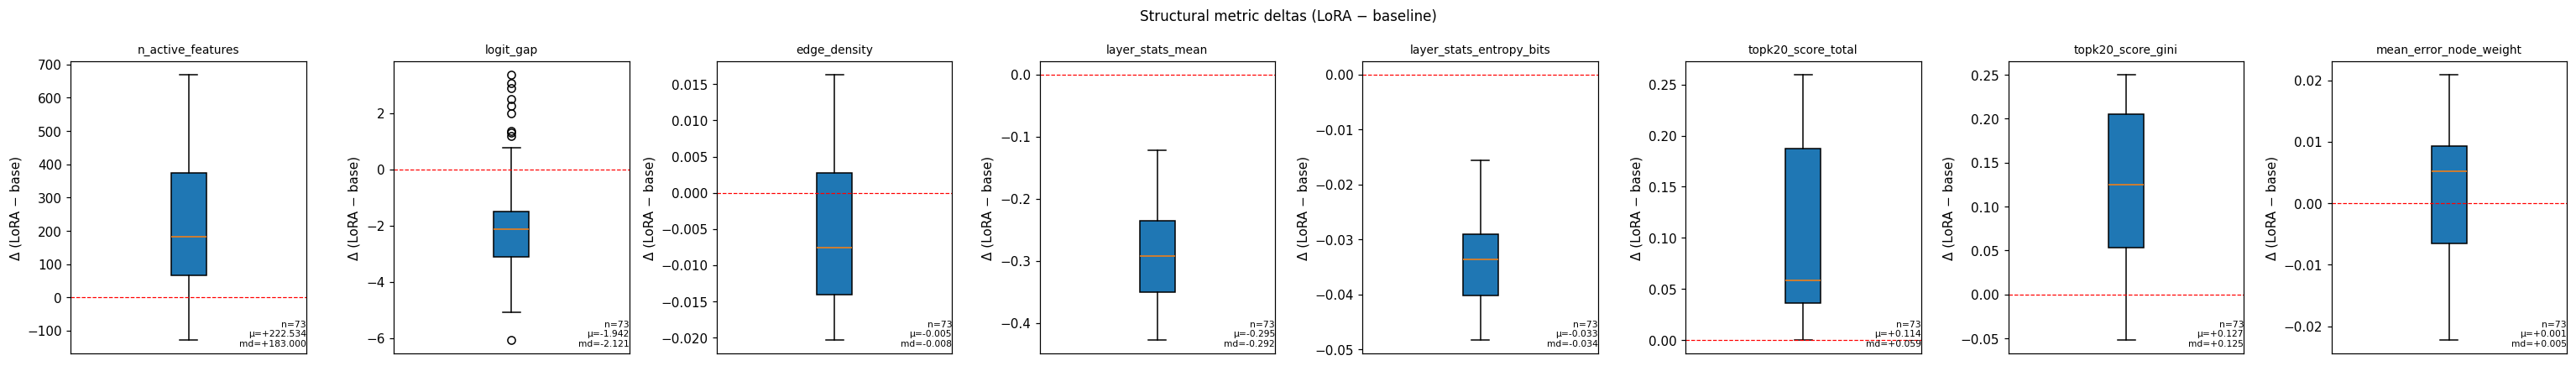

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison/delta_distributions.png


In [16]:
plot_metrics = [m for m in KEY_METRICS if m in df_delta.columns]

if plot_metrics:
    fig, axes = plt.subplots(
        1, len(plot_metrics),
        figsize=(3.5 * len(plot_metrics), 4),
        sharey=False,
    )
    if len(plot_metrics) == 1:
        axes = [axes]

    for ax, dc in zip(axes, plot_metrics):
        vals = df_delta[dc].dropna().values
        ax.boxplot(vals, vert=True, patch_artist=True)
        ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
        ax.set_title(dc[2:], fontsize=9)
        ax.set_ylabel("Δ (LoRA − base)")
        ax.set_xticks([])
        ax.text(
            1.0, 0.02,
            f"n={len(vals)}\nμ={vals.mean():+.3f}\nmd={np.median(vals):+.3f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=7,
        )

    plt.suptitle("Structural metric deltas (LoRA − baseline)", fontsize=11)
    plt.tight_layout()
    _fig_path = FIGURES_DIR / "delta_distributions.png"
    plt.savefig(_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_path}")
else:
    print("No delta columns found — check that metrics overlap between base and LoRA files.")

## 6 — Top-K Jaccard: feature-set overlap base vs LoRA

For each prompt, compute the Jaccard similarity between the set of
`(layer, feat_idx)` pairs in `topk20.features` before and after LoRA.
High Jaccard → same features active; low Jaccard → LoRA changed the circuit.

Jaccard top-K overlap (n=73):
  Overall: mean=0.353  median=0.385  std=0.132  min=0.054  max=0.542

  Yang et al. (ICML 2025) prediction: node sets stable → Jaccard high;
  edge shifts not captured here, but high Jaccard = nodes similar.

Mean Jaccard by family × label:
family            label
geometry_claim    false   0.389
                  true    0.330
numeric_open      true    0.089
numeric_validity  false   0.428
                  true    0.363


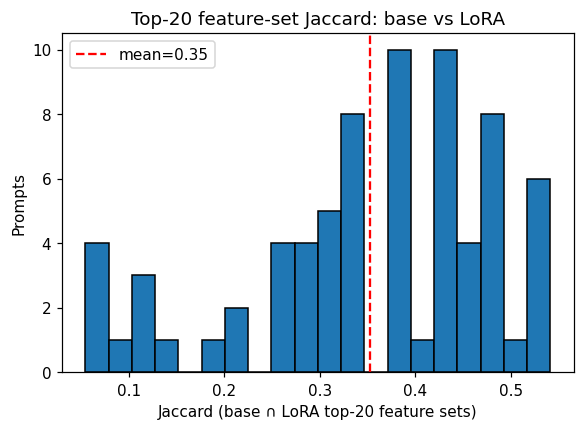

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison/jaccard_histogram.png


In [17]:
def _topk_set(stat: dict) -> set:
    """Extract (layer, feat_idx) pairs from topk20 block."""
    topk = stat.get("topk20")
    if not isinstance(topk, dict):
        return set()
    features = topk.get("features", [])
    return {(int(f["layer"]), int(f["feat_idx"])) for f in features if "layer" in f and "feat_idx" in f}


jaccard_rows = []
for pid in common_ids:
    base_s = base_by_id[pid]
    lora_s = lora_by_id[pid]
    A = _topk_set(base_s)
    B = _topk_set(lora_s)
    if not A and not B:
        continue
    intersection = len(A & B)
    union        = len(A | B)
    jaccard = intersection / union if union > 0 else float("nan")
    jaccard_rows.append({
        "prompt_id": pid,
        "family":    base_s.get("family", "?"),
        "tail":      base_s.get("tail", "?"),
        "label":     _label_str(base_s),
        "jaccard":   jaccard,
        "n_base":    len(A),
        "n_lora":    len(B),
        "n_shared":  intersection,
    })

df_jaccard = pd.DataFrame(jaccard_rows)

print(f"Jaccard top-K overlap (n={len(df_jaccard)}):")
if not df_jaccard.empty:
    vals = df_jaccard["jaccard"].dropna()
    print(f"  Overall: mean={vals.mean():.3f}  median={vals.median():.3f}  "
          f"std={vals.std():.3f}  min={vals.min():.3f}  max={vals.max():.3f}")
    print()
    print("  Yang et al. (ICML 2025) prediction: node sets stable → Jaccard high;")
    print("  edge shifts not captured here, but high Jaccard = nodes similar.")
    print()
    print("Mean Jaccard by family × label:")
    print(df_jaccard.groupby(["family", "label"])["jaccard"].mean().to_string(float_format="{:.3f}".format))

    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(vals, bins=20, edgecolor="k")
    ax.axvline(vals.mean(), color="red", linestyle="--", label=f"mean={vals.mean():.2f}")
    ax.set_xlabel("Jaccard (base ∩ LoRA top-20 feature sets)")
    ax.set_ylabel("Prompts")
    ax.set_title("Top-20 feature-set Jaccard: base vs LoRA")
    ax.legend()
    _fig_path = FIGURES_DIR / "jaccard_histogram.png"
    plt.savefig(_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_path}")
else:
    print("No topk20 data available — check topk20.features field in stats files.")

## 7 — Logit gap: does LoRA sharpen label separation?

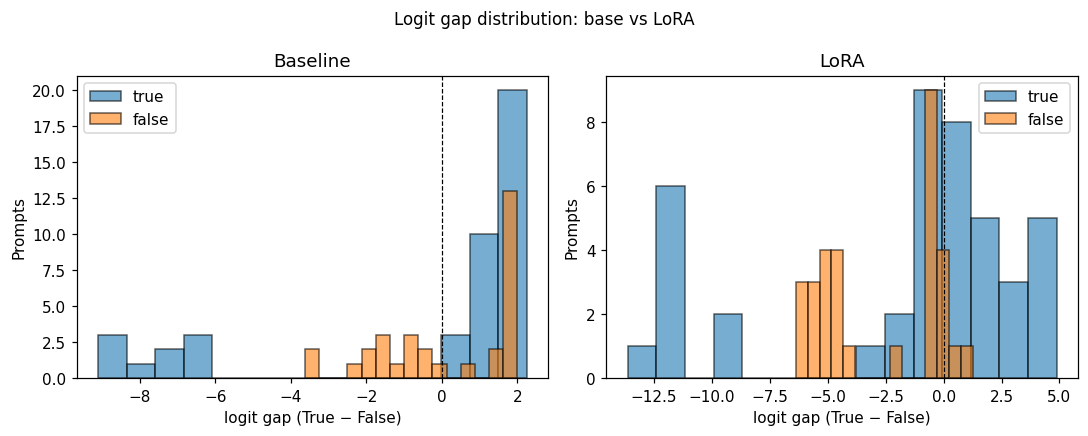

Saved: /Users/Lacus/Documents/ELTE/Thesis/circuit-tracer-main/my_work/results/figures/lora_comparison/logit_gap_comparison.png

Mean logit gap by label (base vs LoRA):
       base_logit_gap  lora_logit_gap
label                                
false          +0.149          -2.717
true           -0.498          -1.758


In [18]:
if "logit_gap" not in df_base.columns or "logit_gap" not in df_lora.columns:
    print("logit_gap column not found — skipping.")
else:
    labels = [_label_str(base_by_id[pid]) for pid in common_ids]
    base_gap = [base_by_id[pid].get("logit_gap") for pid in common_ids]
    lora_gap = [lora_by_id[pid].get("logit_gap") for pid in common_ids]

    df_gap = pd.DataFrame({
        "prompt_id": common_ids,
        "label":     labels,
        "base_logit_gap": base_gap,
        "lora_logit_gap": lora_gap,
    }).dropna(subset=["base_logit_gap", "lora_logit_gap"])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, phase, col in zip(
        axes,
        ["Baseline", "LoRA"],
        ["base_logit_gap", "lora_logit_gap"],
    ):
        for lbl, color in [("true", "tab:blue"), ("false", "tab:orange")]:
            vals = df_gap.loc[df_gap["label"] == lbl, col].dropna()
            ax.hist(vals, bins=15, alpha=0.6, label=lbl, color=color, edgecolor="k")
        ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
        ax.set_xlabel("logit gap (True − False)")
        ax.set_ylabel("Prompts")
        ax.set_title(phase)
        ax.legend()

    plt.suptitle("Logit gap distribution: base vs LoRA", fontsize=11)
    plt.tight_layout()
    _fig_path = FIGURES_DIR / "logit_gap_comparison.png"
    plt.savefig(_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {_fig_path}")

    print()
    print("Mean logit gap by label (base vs LoRA):")
    print(df_gap.groupby("label")[["base_logit_gap", "lora_logit_gap"]].mean().to_string(
        float_format="{:+.3f}".format
    ))

## 8 — Tail vs label dominance check (post-LoRA)

Does the tail-dominance pattern from the baseline hold after LoRA?  
We run logistic regression to predict `tail` and `label` from the structural
features — same logic as `03`.

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score

FEATURE_COLS = [
    "n_active_features", "edge_density", "mean_top50_score",
    "top10_over_top50", "layer_entropy", "mean_error_node_weight",
    "layer_stats_mean", "layer_stats_std", "layer_stats_median",
    "layer_stats_entropy_bits", "topk20_score_total", "topk20_score_gini",
]

for phase_label, flat_stats, src_stats in [
    ("Baseline", base_flat, base_joined),
    ("LoRA",     lora_flat, lora_joined),
]:
    # Filter to binary rows with tail info
    binary_rows = [
        (f, s) for f, s in zip(flat_stats, src_stats)
        if s.get("family") in ("numeric_validity", "geometry_claim")
        and s.get("tail") is not None
    ]
    if len(binary_rows) < 10:
        print(f"{phase_label}: too few binary rows for classifier ({len(binary_rows)}), skipping.")
        continue

    flat_b, stat_b = zip(*binary_rows)
    feat_matrix = []
    valid_idx   = []
    for i, f in enumerate(flat_b):
        row_vals = [f.get(c) for c in FEATURE_COLS]
        if any(v is None for v in row_vals):
            continue
        try:
            feat_matrix.append([float(v) for v in row_vals])
            valid_idx.append(i)
        except (TypeError, ValueError):
            continue

    X = np.array(feat_matrix)
    valid_stats = [stat_b[i] for i in valid_idx]
    y_label = np.array([1 if _binary_label_true(s.get("label")) else 0 for s in valid_stats])
    y_tail  = np.array([s.get("tail", "?") for s in valid_stats])

    if len(X) < 10:
        print(f"{phase_label}: not enough complete rows ({len(X)}), skipping classifier.")
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    cv = StratifiedKFold(n_splits=min(5, len(X)), shuffle=True, random_state=42)

    # Label (True/False) classifier
    try:
        lbl_scores = cross_val_score(
            LogisticRegression(max_iter=500, C=1.0),
            X_scaled, y_label, cv=cv, scoring="accuracy",
        )
        label_acc = f"{lbl_scores.mean():.3f} ± {lbl_scores.std():.3f}"
    except Exception as e:
        label_acc = f"ERROR: {e}"

    # Tail classifier
    n_tail_classes = len(set(y_tail))
    if n_tail_classes >= 2:
        try:
            tail_scores = cross_val_score(
                LogisticRegression(max_iter=500, C=1.0),
                X_scaled, y_tail, cv=StratifiedKFold(n_splits=min(5, len(X)), shuffle=True, random_state=42),
                scoring="accuracy",
            )
            tail_acc = f"{tail_scores.mean():.3f} ± {tail_scores.std():.3f}"
        except Exception as e:
            tail_acc = f"ERROR: {e}"
    else:
        tail_acc = "N/A (single class)"

    print(f"\n=== {phase_label} (n={len(X)}) ===")
    print(f"  Predict True/False label : {label_acc}  (chance 0.500)")
    print(f"  Predict tail             : {tail_acc}  (chance {1/max(n_tail_classes,1):.3f})")


=== Baseline (n=64) ===
  Predict True/False label : 0.732 ± 0.112  (chance 0.500)
  Predict tail             : 0.954 ± 0.062  (chance 0.333)

=== LoRA (n=64) ===
  Predict True/False label : 0.673 ± 0.147  (chance 0.500)
  Predict tail             : 0.862 ± 0.102  (chance 0.333)


## 9 — Thesis summary table

In [20]:
summary_metrics = [
    "n_active_features", "edge_density", "logit_gap",
    "layer_stats_mean", "layer_stats_entropy_bits",
    "topk20_score_total",
]

print(f"{'Metric':<32} {'Baseline':>12} {'LoRA':>12} {'Δ':>10} {'|Δ|/σ_base':>12}")
print("-" * 80)

for m in summary_metrics:
    base_vals = np.array([_flatten_nested(base_by_id[pid]).get(m) for pid in common_ids], dtype=float)
    lora_vals = np.array([_flatten_nested(lora_by_id[pid]).get(m) for pid in common_ids], dtype=float)
    mask = ~(np.isnan(base_vals) | np.isnan(lora_vals))
    if mask.sum() == 0:
        print(f"{m:<32} {'N/A':>12}")
        continue
    bv = base_vals[mask]
    lv = lora_vals[mask]
    delta = (lv - bv).mean()
    sigma_base = bv.std()
    effect_size = abs(delta) / sigma_base if sigma_base > 0 else float("nan")
    print(
        f"{m:<32} {bv.mean():>12.4f} {lv.mean():>12.4f} "
        f"{delta:>+10.4f} {effect_size:>12.3f}"
    )

print()
print("Interpretation guide:")
print("  |Δ|/σ_base < 0.2 → negligible effect")
print("  |Δ|/σ_base 0.2–0.5 → small effect")
print("  |Δ|/σ_base > 0.5 → medium/large effect (worth discussing in thesis)")

Metric                               Baseline         LoRA          Δ   |Δ|/σ_base
--------------------------------------------------------------------------------
n_active_features                  23557.8904   23780.4247  +222.5342        0.045
edge_density                           0.1201       0.1153    -0.0048        0.976
logit_gap                             -0.2232      -2.1652    -1.9419        0.625
layer_stats_mean                       8.7772       8.4823    -0.2950        1.192
layer_stats_entropy_bits               4.2417       4.2084    -0.0333        1.080
topk20_score_total                     0.0135       0.1272    +0.1137        4.862

Interpretation guide:
  |Δ|/σ_base < 0.2 → negligible effect
  |Δ|/σ_base 0.2–0.5 → small effect
  |Δ|/σ_base > 0.5 → medium/large effect (worth discussing in thesis)


## 10 — Export delta CSV for thesis / lora_compare parity

In [ ]:
csv_path = FIGURES_DIR / "lora_delta_per_prompt.csv"
df_delta.reset_index().to_csv(csv_path, index=False)
print(f"Per-prompt delta CSV saved: {csv_path}")

summary_csv_path = FIGURES_DIR / "lora_delta_summary.csv"
if not df_delta.empty:
    summary_by_group = df_delta.groupby(["family", "label", "tail"])[
        [c for c in delta_cols if c in df_delta.columns]
    ].mean()
    summary_by_group.to_csv(summary_csv_path)
    print(f"Summary CSV saved: {summary_csv_path}")

if not df_jaccard.empty:
    jac_csv = FIGURES_DIR / "jaccard_per_prompt.csv"
    df_jaccard.to_csv(jac_csv, index=False)
    print(f"Jaccard CSV saved: {jac_csv}")

print()
print("All outputs in:", FIGURES_DIR)